# Member C — Project Part 4: Learned Fusion, Calibration, Locked Evaluation, and Monitoring Utilities

This notebook is the **primary executable notebook for Project Part 4**.

Project organization:

1. **Part 1 — Scraping and cleaning**
2. **Part 2 — Label/data foundation and leakage-safe model roles**
3. **Part 3 — Member 1 tabular CatBoost + Member 2 Persian ParsBERT**
4. **Part 4 — This notebook: late fusion, threshold calibration, locked-test evaluation, explainability, temporal aggregation, and active-learning acquisition**

The source modules and artifact names keep the historical internal labels **Phase 4–8** for provenance, but these stages together are now Project **Part 4**.

## What problem does Part 4 solve?

Member 1 and Member 2 view the same post through different modalities:

- Member 1: structured metadata, counts, temporal/category/behavioral signals;
- Member 2: contextual Persian text through ParsBERT.

Part 4 asks whether combining those complementary signals can outperform either branch alone **without introducing stacking leakage**.

The final system is **learned late fusion**. It does not concatenate a 768-dimensional Transformer embedding with the tabular matrix. Instead it uses:

- leakage-safe Member 1 scalar prediction;
- leakage-safe Member 2 scalar prediction;
- their arithmetic mean;
- signed difference and absolute disagreement;
- Member 1's predefined engineered tabular features.

A shallow CatBoost regressor learns when these signals should reinforce or modify one another.

## Why late fusion?

Late fusion is appropriate here because the labeled dataset is relatively small and the base branches already specialize in their modalities. It:

- keeps the fusion feature space compact;
- reuses OOF predictions cleanly;
- reduces overfitting risk compared with a high-dimensional joint embedding model;
- lets us compare against simple averaging and linear stacking;
- makes disagreement between the two modalities explicit;
- keeps Member 1/Member 2 reusable as independent components.

## Evaluation discipline

The fusion model is trained only on **4,226 OOF-aligned training rows**. Candidate selection and prediction-threshold calibration use **452 validation rows**. The **453-row test** is loaded only by the locked-test evaluation stage after the candidate and thresholds have been frozen.

The test has already been opened in the finalized project. Re-running it here is valid for exact reproduction, but its result must not be used for new tuning.

## Frozen final result

Selected candidate: `hybrid_catboost_rmse_depth3`

Locked-test MAE: **0.9174**

Test recall:

- Low: **87.54%**
- Moderate: **41.79%**
- High: **52.38%**
- Very High: **76.92%**

This meets **3 of 4 internal project recall objectives**. Moderate remains the improvement area.

Deployment interpretation is separate from the internal gate: the frozen project status is **candidate for a limited human-in-the-loop risk-monitoring overlay**, not autonomous diagnosis or emergency decision-making.


## 0. Execution parameters — reproducing evidence without accidentally retuning it

`RUN_LOCKED_TEST=True` reproduces the already-recorded final test evaluation.

### Why is there an explicit switch?

A test set has a special scientific role: it estimates generalization **after** development choices are fixed. Making test access explicit reduces accidental peeking.

This project has already completed its one-time test evaluation, so exact reproduction is allowed. What is not allowed is:

1. inspect the reproduced test result,
2. change model features/hyperparameters/thresholds because of it,
3. evaluate the same test again,
4. call the new number an untouched test result.

Any new improvement cycle needs development-only data and eventually a **new untouched confirmation set**.

`RESET_NOTEBOOK_RUN=True` creates a clean run directory. Accepted source artifacts are copied into it rather than modified in place. This gives the notebook a sandboxed experiment directory whose outputs can be compared with the frozen package.

`REGENERATE_REPORT_FIGURES=True` only regenerates visualizations from the reproduced outputs; it does not alter the trained model.


In [1]:
from pathlib import Path
import os
import sys
import json
import shutil
import subprocess
import hashlib
import importlib
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, current.parent, current.parent.parent]
    for candidate in candidates:
        if (candidate / "src/train_fusion.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the Phase 4–8 project root. "
        "Open this notebook from the packaged notebooks directory."
    )

ROOT = find_project_root()
RUN_ROOT = ROOT / "notebook_run"
PYTHON = sys.executable

RESET_NOTEBOOK_RUN = True
RUN_LOCKED_TEST = True
REGENERATE_REPORT_FIGURES = True

if RESET_NOTEBOOK_RUN and RUN_ROOT.exists():
    shutil.rmtree(RUN_ROOT)

for folder in ["data", "config", "models", "outputs", "templates"]:
    (RUN_ROOT / folder).mkdir(parents=True, exist_ok=True)

# Copy immutable inputs/configuration required by the scripts.
for path in (ROOT / "data").iterdir():
    if path.is_file():
        shutil.copy2(path, RUN_ROOT / "data" / path.name)
for path in (ROOT / "config").iterdir():
    if path.is_file():
        shutil.copy2(path, RUN_ROOT / "config" / path.name)
for path in (ROOT / "templates").iterdir():
    if path.is_file():
        shutil.copy2(path, RUN_ROOT / "templates" / path.name)

print("Project root:", ROOT)
print("Notebook run root:", RUN_ROOT)
print("Python:", PYTHON)
print("Locked test reproduction enabled:", RUN_LOCKED_TEST)

Project root: /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8
Notebook run root: /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run
Python: /opt/pyvenv/bin/python3
Locked test reproduction enabled: True


**How to interpret the setup output**

The notebook prints:

- the project root it discovered;
- the fresh `notebook_run/` directory;
- the Python executable;
- whether locked-test reproduction is enabled.

A correct run should operate entirely inside the packaged project and should never overwrite the accepted `data/`, `models/`, or `outputs/` reference artifacts.


## 0.1 Command helper and import path — keeping notebook orchestration separate from implementation

The notebook sets `PYTHONPATH` to the packaged `src/` directory and executes the main stages as command-line Python modules.

### Why not copy every implementation into notebook cells?

The notebook makes the reasoning explicit while keeping production-quality implementation modular.

- The notebook explains **why** each stage exists.
- `src/` contains the reusable implementation.
- `tests/` verifies invariants.
- command output remains visible in the notebook for reproducibility.

The input check confirms that the exact accepted Member 1 and Member 2 OOF/holdout handoffs are present.

### Why the base-model prediction type matters

For fusion training, each Member 1/Member 2 training score must be **OOF**: produced by a base model that did not train on that row.

For validation/test, the score is the mean of the five corresponding fold models.

Using an in-sample full-training prediction for fusion train would be stacking leakage; replacing fold-ensemble holdout scores with a different full-train model would create a train/holdout representation mismatch.


In [2]:
os.environ["PYTHONPATH"] = str(ROOT / "src") + os.pathsep + os.environ.get("PYTHONPATH", "")

def run_command(command, cwd=ROOT, allowed_returncodes=(0,)):
    command = [str(value) for value in command]
    print("\n$", " ".join(command))
    completed = subprocess.run(
        command,
        cwd=cwd,
        env=os.environ.copy(),
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    if completed.returncode not in allowed_returncodes:
        raise RuntimeError(
            f"Command failed with return code {completed.returncode}: {command}"
        )
    return completed

required_data = [
    "modeling_manifest_v2.csv",
    "member1_handoff.csv.gz",
    "member1_oof_predictions.csv",
    "member1_validation_predictions_for_fusion.csv",
    "member1_test_predictions_for_fusion.csv",
    "member2_oof_predictions_deterministic.csv",
    "member2_validation_predictions_fold_ensemble.csv",
    "member2_test_predictions_fold_ensemble.csv",
]
missing = [name for name in required_data if not (RUN_ROOT / "data" / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing Phase 4 inputs: {missing}")

display(pd.DataFrame({
    "file": required_data,
    "size_bytes": [(RUN_ROOT / "data" / name).stat().st_size for name in required_data],
}))
print("All accepted base-model handoff files are present.")

,file,size_bytes
0,modeling_manifest_v2.csv,1851492
1,member1_handoff.csv.gz,1188067
2,member1_oof_predictions.csv,214730
3,member1_validation_predictions_for_fusion.csv,33454
4,member1_test_predictions_for_fusion.csv,31000
5,member2_oof_predictions_deterministic.csv,212495
6,member2_validation_predictions_fold_ensemble.csv,47869
7,member2_test_predictions_fold_ensemble.csv,45340


All accepted base-model handoff files are present.


**How to interpret the input check**

The required files are not interchangeable merely because they contain a column called `prediction`.

The intended contract is:

- **train:** one held-out OOF prediction per row;
- **validation/test:** deterministic mean of the five base fold models;
- **embargo:** excluded.

This consistency lets the fusion model learn from realistic base-model errors rather than memorized training scores.


# Historical Phase 4 — Align and validate Member 1 + Member 2 handoffs

The first fusion operation is **data alignment**, not model fitting.

Rows are joined by normalized `unique_post_id`, never by their current CSV row order. This prevents a serious failure mode in which Member 1's prediction for one post is accidentally paired with Member 2's prediction/target for another.

The loader verifies:

- expected train/validation/test counts;
- unique ID coverage;
- no duplicate predictions;
- correct role labels;
- valid OOF-fold assignments;
- absence of embargo rows.

## Why verify prediction ranges too?

Extreme or non-finite values can reveal malformed inference files before they reach the stacker. Range checks are a sanity test, not a substitute for model evaluation.

## Why no raw Transformer embedding here?

The final primary fusion uses Member 2's **scalar stress prediction**, not the 768-D CLS embedding. The scalar has a clean OOF definition and is directly optimized for the target. Using fold-specific OOF embeddings together with a different full-train encoder for holdouts would create a representation mismatch, and a 768-D vector would increase overfitting risk on ~4k training rows.


In [3]:
sys.path.insert(0, str(ROOT / "src"))
from common import load_project_role

train_data = load_project_role(RUN_ROOT, "train")
validation_data = load_project_role(RUN_ROOT, "validation")
test_data = load_project_role(RUN_ROOT, "test")

role_summary = pd.DataFrame([
    {
        "role": role,
        "rows": len(frame),
        "unique_ids": frame["unique_post_id"].nunique(),
        "member1_prediction_min": frame["member1_prediction"].min(),
        "member1_prediction_max": frame["member1_prediction"].max(),
        "member2_prediction_min": frame["member2_prediction"].min(),
        "member2_prediction_max": frame["member2_prediction"].max(),
    }
    for role, frame in [
        ("train", train_data),
        ("validation", validation_data),
        ("test", test_data),
    ]
])
display(role_summary)

assert len(train_data) == 4226
assert len(validation_data) == 452
assert len(test_data) == 453
assert train_data["oof_fold"].notna().all()
assert train_data["oof_fold"].between(0, 4).all()

display(
    train_data.groupby(["oof_fold", "clinical_class"])
    .size()
    .unstack(fill_value=0)
)

,role,rows,unique_ids,member1_prediction_min,member1_prediction_max,member2_prediction_min,member2_prediction_max
0,train,4226,4226,1.0,7.820622,0.173948,8.568514
1,validation,452,452,1.0,7.146049,0.657135,8.267718
2,test,453,453,1.0,6.843696,0.620041,8.280279


clinical_class,High,Low,Moderate,Very High
oof_fold,,,,
0,147,451,189,57
1,147,451,189,57
2,148,452,191,57
3,148,452,190,57
4,146,451,189,57


**Phase 4 result**

After alignment, the fusion data contain:

- **4,226** training rows with leakage-safe Member 1 + Member 2 OOF scores;
- **452** official validation rows;
- **453** locked-test rows.

The displayed fold-by-class table is an important diagnostic: it confirms that the training signal is distributed across all five OOF folds and classes rather than being concentrated in one fold.

At this point, the fusion model can be trained without ever seeing an in-sample base prediction for its own training row.


# Historical Phase 5 — Compare fusion strategies instead of assuming a complex model is best

`train_fusion.py` deliberately evaluates a ladder of candidates.

## Baselines

1. **Member 1 only** — how much the structured branch can do alone.
2. **Member 2 only** — how much the Persian text branch can do alone.
3. **Fixed weighted averages** — tests whether a simple ensemble is already sufficient.

A learned fusion model should earn its extra complexity by improving on these baselines.

## Linear and Ridge stackers

A linear stacker learns coefficients for the two base predictions. Ridge adds an L2 penalty:

\[
\min_{\beta}\sum_i w_i(y_i-X_i\beta)^2+\alpha\|\beta\|_2^2
\]

Ridge is useful when predictors are correlated — which Member 1 and Member 2 scores naturally are — because regularization discourages unstable large coefficients.

## Scalar CatBoost stackers

Shallow CatBoost models use only the two scalar base scores. Monotone constraints require the fused prediction not to decrease when either base stress score increases, all else equal. This is a useful sanity prior for an ordered stress target.

## Hybrid CatBoost candidates

The hybrid models additionally receive Member 1's predefined tabular features plus:

- `base_mean = (M1 + M2)/2`;
- `base_difference = M2 - M1`;
- `base_absolute_difference = |M2-M1|`.

Why explicitly add mean/disagreement if both scores already exist? A tree model can theoretically reconstruct some relationships, but providing these low-cost interaction summaries makes consensus and disagreement directly accessible to shallow trees.

### Why CatBoost?

CatBoost is well suited to this stacker because the feature matrix mixes numeric and categorical fields and the dataset is small-to-medium. Tree boosting can model nonlinear conditional trust, e.g. *trust the text score more in one context but adjust it when structured indicators disagree*. A shallow depth limits complexity.

## Training weights

Every learned candidate uses the frozen `training_sample_weight` from Part 2. The fusion does not invent a new weighting policy.

## Important principle

Candidate comparison uses **training + validation only**. The locked test is not loaded by `train_fusion.py`.


In [4]:
run_command([
    PYTHON,
    ROOT / "src/train_fusion.py",
    "--project-root", RUN_ROOT,
])

training_status = json.loads(
    (RUN_ROOT / "outputs/training_status.json").read_text(encoding="utf-8")
)
leaderboard = pd.read_csv(RUN_ROOT / "outputs/candidate_leaderboard.csv")
bundle = json.loads(
    (RUN_ROOT / "models/fusion_bundle.json").read_text(encoding="utf-8")
)

display(pd.DataFrame([training_status]))
display(
    leaderboard[
        [
            "candidate",
            "feature_profile",
            "validation_mae",
            "validation_rmse",
            "validation_pearson",
            "threshold_status",
            "feasible_threshold_count",
            "validation_macro_f1",
            "validation_very_high_precision",
            "selected",
        ]
    ].head(15)
)
print("Selected candidate:", bundle["selected_candidate"])
print("Feature profile:", bundle["feature_profile"])
print("Number of selected features:", len(bundle["features"]))


$ /opt/pyvenv/bin/python3 /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/src/train_fusion.py --project-root /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run


{
  "status": "complete",
  "selected_candidate": "hybrid_catboost_rmse_depth3",
  "feature_profile": "hybrid",
  "validation_constraints_pass": true,
  "validation_failed_constraints": [],
  "test_loaded_or_evaluated": false,
  "model_sha256": "b441032baa60ed370203120713e412c3595e85f05f34d695988b6df768726841",
  "bundle_sha256": "d266c199d7322e3d9faa4226f852ac458e243ff6ca7716c728ff0b8b4afefbdf"
}



,status,selected_candidate,feature_profile,validation_constraints_pass,validation_failed_constraints,test_loaded_or_evaluated,model_sha256,bundle_sha256
0,complete,hybrid_catboost_rmse_depth3,hybrid,True,[],False,b441032baa60ed370203120713e412c3595e85f05f34d6...,d266c199d7322e3d9faa4226f852ac458e243ff6ca7716...


,candidate,feature_profile,validation_mae,validation_rmse,validation_pearson,threshold_status,feasible_threshold_count,validation_macro_f1,validation_very_high_precision,selected
0,hybrid_catboost_rmse_depth3,hybrid,0.834757,1.133565,0.857657,feasible,4485,0.671679,0.791667,True
1,hybrid_catboost_rmse_depth4,hybrid,0.835160,1.133484,0.857165,feasible,2222,0.653317,0.730769,False
2,weighted_blend_member2_0.80,scalar,0.842190,1.125543,0.864515,feasible,4750,0.674515,0.689655,False
3,weighted_blend_member2_0.95,scalar,0.817628,1.134044,0.862292,feasible,9682,0.671669,0.689655,False
4,member2_only,scalar,0.814541,1.144482,0.860464,feasible,10873,0.665355,0.689655,False
5,weighted_blend_member2_1.00,scalar,0.814541,1.144482,0.860464,feasible,10873,0.665355,0.689655,False
6,scalar_catboost_depth3,scalar,0.822555,1.128538,0.858277,feasible,4675,0.666246,0.678571,False
7,weighted_blend_member2_0.90,scalar,0.822549,1.127340,0.863629,feasible,7864,0.663889,0.678571,False
8,hybrid_catboost_mae_depth4,hybrid,0.734985,1.099061,0.864075,feasible,839,0.634455,0.678571,False
9,weighted_blend_member2_0.85,scalar,0.831564,1.124453,0.864423,feasible,5494,0.676846,0.677419,False


Selected candidate: hybrid_catboost_rmse_depth3
Feature profile: hybrid
Number of selected features: 72


**How to interpret the candidate leaderboard**

The leaderboard should not be read as “lowest MAE automatically wins.”

The project has both:

- a continuous regression goal (MAE/RMSE/correlation), and
- class-specific internal recall objectives after thresholding.

Therefore each candidate receives its own validation threshold search. A candidate can have excellent MAE but still be operationally unsuitable if no ordered threshold triple reaches the minimum recalls.

The selected final model is the shallow `hybrid_catboost_rmse_depth3`, while a scalar CatBoost model is stored separately as a simpler fallback profile.


# Historical Phase 6 — Constrained threshold calibration and model freeze

The neural/tabular/fusion models output a **continuous stress score**. Operational classes require three increasing cut points in predicted-score space.

True-score classes remain:

- Low: ≤3
- Moderate: (3,5]
- High: (5,7]
- Very High: >7

The **prediction thresholds do not have to equal 3/5/7** because a regression model can be systematically compressed or shifted. Calibration maps model-score space to the desired operating classes without redefining the true labels.

## Threshold search algorithm

The code builds candidate cut points between distinct validation predictions and searches ordered triples:

\[
t_1 < t_2 < t_3
\]

A triple is feasible only if validation recall satisfies the project floors:

- Low ≥ 0.75
- Moderate ≥ 0.50
- High ≥ 0.50
- Very High ≥ 0.75

The search is implemented efficiently using per-class sorted predictions and cumulative counts rather than recomputing a full confusion matrix from scratch for every possible triple.

## Why constraints first?

If we optimized only overall accuracy, the large Low class could dominate the objective. Requiring minimum class recalls first prevents a high-accuracy solution that neglects a minority class.

## How feasible solutions are ranked

Among threshold triples that already satisfy all recall floors, the project prioritizes:

1. **Very High precision** — reduce false alarms in the highest-priority review queue while preserving its recall floor;
2. **macro F1** — balance all four classes;
3. **High precision**;
4. lower validation MAE as a later tie-breaker at the candidate level.

Candidate model selection follows the same safety-oriented ranking among feasible learned models.

This is why the final selected model is not necessarily the one with the absolute lowest validation MAE.

## Frozen operating point

The selected thresholds are approximately:

- Low / Moderate: **3.0954**
- Moderate / High: **4.9052**
- High / Very High: **6.4621**

Once the candidate, feature order, thresholds, input hashes, and model file are frozen, test evaluation can begin.


In [5]:
validation_metrics = json.loads(
    (RUN_ROOT / "outputs/validation_metrics.json").read_text(encoding="utf-8")
)
threshold_candidates = pd.read_csv(
    RUN_ROOT / "outputs/selected_threshold_search_top100.csv"
)

print("Frozen thresholds:", bundle["thresholds"])
print(
    "Validation constraints pass:",
    validation_metrics["classification"]["constraints_pass"],
)
display(
    pd.DataFrame({
        "class": ["Low", "Moderate", "High", "Very High"],
        "recall": [
            validation_metrics["classification"]["recall_by_class"][label]
            for label in ["Low", "Moderate", "High", "Very High"]
        ],
        "precision": [
            validation_metrics["classification"]["precision_by_class"][label]
            for label in ["Low", "Moderate", "High", "Very High"]
        ],
        "required_recall": [0.75, 0.50, 0.50, 0.75],
    })
)
display(threshold_candidates.head(10))

Frozen thresholds: [3.0954385027019997, 4.905160815295, 6.4621351159455]
Validation constraints pass: True


,class,recall,precision,required_recall
0,Low,0.845118,0.919414,0.75
1,Moderate,0.582090,0.382353,0.50
2,High,0.523810,0.622642,0.50
3,Very High,0.760000,0.791667,0.75


,rank,threshold_low_moderate,threshold_moderate_high,threshold_high_very_high,accuracy,macro_f1,low_precision,moderate_precision,high_precision,very_high_precision,low_recall,moderate_recall,high_recall,very_high_recall
0,1,3.095439,4.905161,6.462135,0.756637,0.671679,0.919414,0.382353,0.622642,0.791667,0.845118,0.582090,0.52381,0.76
1,2,2.933251,4.905161,6.462135,0.747788,0.671295,0.927757,0.375000,0.622642,0.791667,0.821549,0.626866,0.52381,0.76
2,3,2.991802,4.905161,6.462135,0.750000,0.671069,0.924812,0.376147,0.622642,0.791667,0.828283,0.611940,0.52381,0.76
3,4,3.162018,4.905161,6.462135,0.763274,0.670553,0.911348,0.387097,0.622642,0.791667,0.865320,0.537313,0.52381,0.76
4,5,3.077864,4.905161,6.462135,0.754425,0.670508,0.919118,0.378641,0.622642,0.791667,0.841751,0.582090,0.52381,0.76
5,6,2.855034,4.905161,6.462135,0.743363,0.670332,0.930502,0.370690,0.622642,0.791667,0.811448,0.641791,0.52381,0.76
6,7,2.909612,4.905161,6.462135,0.745575,0.670138,0.927481,0.371681,0.622642,0.791667,0.818182,0.626866,0.52381,0.76
7,8,2.971600,4.905161,6.462135,0.747788,0.669910,0.924528,0.372727,0.622642,0.791667,0.824916,0.611940,0.52381,0.76
8,9,3.128633,4.905161,6.462135,0.758850,0.669793,0.913669,0.381443,0.622642,0.791667,0.855219,0.552239,0.52381,0.76
9,10,3.159440,4.905161,6.462135,0.761062,0.669373,0.911032,0.382979,0.622642,0.791667,0.861953,0.537313,0.52381,0.76


**Phase 6 result**

Validation satisfies all four internal recall objectives.

`fusion_bundle.json` acts as the frozen inference contract. It records:

- selected candidate;
- exact feature order;
- categorical features;
- CatBoost configuration;
- score clipping range;
- calibrated thresholds;
- validation metrics;
- hashes of important input artifacts.

This is important because a model file without its feature order and thresholds is not enough to reproduce the same system.


# Historical Phase 7.1 — Generate leakage-safe fusion OOF predictions

The selected fusion configuration is retrained five times so that every **training** row receives a fusion prediction from a model that did not train on that row's OOF fold.

## Why generate OOF predictions for the fusion itself?

The final full-training fusion model can predict the training rows, but those predictions are optimistically in-sample. They should not be used for honest residual/error analysis or as a feature in another meta-model.

OOF generation gives a realistic training-set diagnostic:

For fold \(k\):

1. train the fusion on the other four folds;
2. predict only fold \(k\);
3. repeat for all five folds;
4. concatenate the held-out predictions.

Because Part 2 already keeps connected components inside a single OOF fold, the fusion OOF process inherits the author/thread/duplicate leakage barrier.

This distinction — **in-sample prediction versus OOF prediction** — is central to understanding stacking.


In [6]:
run_command([
    PYTHON,
    ROOT / "src/generate_fusion_oof.py",
    "--project-root", RUN_ROOT,
])

fusion_oof_metrics = json.loads(
    (RUN_ROOT / "outputs/fusion_oof_metrics.json").read_text(encoding="utf-8")
)
fusion_oof = pd.read_csv(RUN_ROOT / "outputs/fusion_oof_predictions.csv")

display(pd.json_normalize(fusion_oof_metrics["continuous"]))
display(
    fusion_oof.groupby(["fold", "true_class"])
    .size()
    .unstack(fill_value=0)
)
print("Fusion OOF rows:", len(fusion_oof))
print("Duplicate fusion OOF IDs:", fusion_oof["unique_post_id"].duplicated().sum())


$ /opt/pyvenv/bin/python3 /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/src/generate_fusion_oof.py --project-root /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run


{
  "status": "complete",
  "rows": 4226,
  "mae": 0.9261083191702765,
  "pearson": 0.8275386012869556
}



,mae,rmse,pearson,spearman,prediction_min,prediction_max
0,0.926108,1.230119,0.827539,0.820162,1.0,8.600114


true_class,High,Low,Moderate,Very High
fold,,,,
0,147,451,189,57
1,147,451,189,57
2,148,452,191,57
3,148,452,190,57
4,146,451,189,57


Fusion OOF rows: 4226
Duplicate fusion OOF IDs: 0


**Phase 7.1 result**

There should be exactly **4,226** fusion OOF rows, one per training ID, with no duplicates.

These OOF values are useful for:

- honest training residual analysis;
- comparing train-side error with validation/test;
- future leakage-safe meta-model experiments.

They are not used to retroactively select thresholds from the locked test.


# Historical Phase 7.2 — Reproduce the locked final test exactly once as evidence

The model candidate and thresholds are already frozen before this stage. `evaluate_locked_test.py` is the only final-development script that loads the test role.

The script requires an explicit `--confirm-lock` acknowledgement. The packaged reproduction also uses `--force` because the test was already evaluated historically and this run is reproducing the same frozen evidence.

## Why test locking matters

Model development contains many degrees of freedom: features, hyperparameters, loss, model family, thresholds, and candidate ranking. If we repeatedly inspect test outcomes while changing those choices, the test becomes a hidden validation set and the reported generalization estimate becomes biased.

Therefore:

- **validation** is allowed to influence development;
- **test** is allowed to influence the final conclusion;
- **test must not influence a new model that is then evaluated on the same test as if untouched**.

Any future improvement requires a new confirmation set.

## What is measured?

Continuous metrics include MAE, RMSE, Pearson/Spearman association. Ordered-class metrics include precision, recall, F1, confusion matrix, and Very-High PR-AUC.

MAE answers “how far is the predicted score from the target on average?” Class recall answers a different question: “among all true posts in this class, what fraction did we recover?” Both views are necessary.


In [7]:
if RUN_LOCKED_TEST:
    run_command([
        PYTHON,
        ROOT / "src/evaluate_locked_test.py",
        "--project-root", RUN_ROOT,
        "--confirm-lock",
        "--force",
    ])

    final_metrics = json.loads(
        (RUN_ROOT / "outputs/final_metrics.json").read_text(encoding="utf-8")
    )
    test_metrics = final_metrics["test"]
    display(pd.DataFrame([
        {
            "split": "validation",
            **final_metrics["validation"]["continuous"],
            "accuracy": final_metrics["validation"]["classification"]["accuracy"],
            "macro_f1": final_metrics["validation"]["classification"]["macro_f1"],
            "gate": final_metrics["validation_gate"],
        },
        {
            "split": "test",
            **final_metrics["test"]["continuous"],
            "accuracy": final_metrics["test"]["classification"]["accuracy"],
            "macro_f1": final_metrics["test"]["classification"]["macro_f1"],
            "gate": final_metrics["test_gate"],
        },
    ]))
    display(pd.DataFrame({
        "class": ["Low", "Moderate", "High", "Very High"],
        "test_recall": [
            test_metrics["classification"]["recall_by_class"][label]
            for label in ["Low", "Moderate", "High", "Very High"]
        ],
        "test_precision": [
            test_metrics["classification"]["precision_by_class"][label]
            for label in ["Low", "Moderate", "High", "Very High"]
        ],
        "required_recall": [0.75, 0.50, 0.50, 0.75],
    }))
else:
    print("Locked test reproduction was disabled in the parameter cell.")


$ /opt/pyvenv/bin/python3 /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/src/evaluate_locked_test.py --project-root /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run --confirm-lock --force


{
  "status": "locked_test_evaluated",
  "evaluated_at_utc": "2026-08-06T13:40:17.369130+00:00",
  "selected_candidate": "hybrid_catboost_rmse_depth3",
  "thresholds": [
    3.0954385027019997,
    4.905160815295,
    6.4621351159455
  ],
  "model_sha256": "b441032baa60ed370203120713e412c3595e85f05f34d695988b6df768726841",
  "bundle_sha256_before_test_update": "d266c199d7322e3d9faa4226f852ac458e243ff6ca7716c728ff0b8b4afefbdf",
  "test_prediction_sha256": "9edf97b35748b48b60238e1b968bc00acb0cc018e5514b56daf334e90f896d18",
  "constraints_pass": false,
  "failed_recall_constraints": [
    "Moderate"
  ]
}



,split,mae,rmse,pearson,spearman,prediction_min,prediction_max,accuracy,macro_f1,gate
0,validation,0.834757,1.133565,0.857657,0.818490,1.0,7.756248,0.756637,0.671679,True
1,test,0.917356,1.245912,0.833266,0.790059,1.0,7.676382,0.752759,0.628420,False


,class,test_recall,test_precision,required_recall
0,Low,0.875421,0.915493,0.75
1,Moderate,0.417910,0.354430,0.50
2,High,0.523810,0.568966,0.50
3,Very High,0.769231,0.625000,0.75


**Locked-test interpretation**

Final test recalls are:

- **Low:** 87.54% — passes the 75% internal objective
- **Moderate:** 41.79% — misses the 50% internal objective
- **High:** 52.38% — passes the 50% internal objective
- **Very High:** 76.92% — passes the 75% internal objective

So the correct project statement is:

> **3 of 4 internal recall targets were met; Moderate remains the main improvement area.**

The internal recall floors are project evaluation targets, **not medical/regulatory standards**.

Very High recall is 20/26 = 76.92%, with precision 62.50%. This is encouraging for prioritizing severe signals, but the support of 26 is small, so it is not evidence of clinical safety.

The system's frozen deployment interpretation is therefore:

> **candidate for a limited human-in-the-loop risk-monitoring overlay**

It may score posts and help prioritize a private review queue. It must **not** be presented as autonomous diagnosis, a crisis decision-maker, or automatic emergency escalation.

Moderate errors occur toward both neighboring classes, so the result suggests genuine overlap in the middle score region rather than one simple test-threshold mistake. The correct next improvement is new development data around those boundaries — not retuning the opened test.


# Historical Phase 8.1 — Explainability with CatBoost importance and SHAP

After the model is frozen, this stage asks **how the trained fusion uses its inputs**.

Two explanation summaries are shown:

1. **CatBoost global feature importance** — a model-specific aggregate measure of how features participate in the fitted trees.
2. **SHAP values** — additive local contributions derived from Shapley-value ideas. For one prediction:

\[
\hat y = \text{baseline} + \sum_j \phi_j
\]

where \(\phi_j\) is the contribution assigned to feature \(j\).

Mean absolute SHAP across validation rows summarizes how strongly a feature changes predictions on average, regardless of direction.

## Why use SHAP after training rather than for automatic feature selection?

Explainability and feature selection are different tasks.

The project uses SHAP to **audit and interpret** the frozen model. Removing features after seeing SHAP would create a new model and require revalidation. Correlated inputs such as `member2_prediction` and `base_mean` can also share attribution, so importance should not be interpreted as a unique causal decomposition.

## Local smoke test

`predict_fusion.py` loads the exact saved feature contract and model, generates a prediction on the provided template, and optionally writes row-level SHAP values. This tests that the explanation path uses the same transformation as inference.

SHAP indicates model behavior, not causality and not clinical explanation.


In [8]:
global_importance = pd.read_csv(
    RUN_ROOT / "outputs/global_feature_importance.csv"
)
shap_summary = pd.read_csv(
    RUN_ROOT / "outputs/validation_shap_summary.csv"
)

display(Markdown("### Top global CatBoost features"))
display(global_importance.head(20))
display(Markdown("### Top validation SHAP contributions"))
display(shap_summary.head(20))

run_command([
    PYTHON,
    ROOT / "src/predict_fusion.py",
    "--input", RUN_ROOT / "templates/fusion_input_template.csv",
    "--output", RUN_ROOT / "outputs/example_fusion_predictions.csv",
    "--shap-output", RUN_ROOT / "outputs/example_fusion_shap.csv",
    "--project-root", RUN_ROOT,
])

display(pd.read_csv(RUN_ROOT / "outputs/example_fusion_predictions.csv"))
display(pd.read_csv(RUN_ROOT / "outputs/example_fusion_shap.csv").head(15))

### Top global CatBoost features

,feature,importance
0,base_mean,42.426698
1,member2_prediction,41.315227
2,member1_prediction,2.983195
3,post_pos_emoji,2.004879
4,post_neg_emoji,1.795264
5,base_difference,0.939318
6,post_emoji_per_100_words,0.580484
7,post_temp_neg_ratio,0.488968
8,sub_category,0.384120
9,post_neg_count,0.349168


### Top validation SHAP contributions

,feature,mean_absolute_shap,mean_signed_shap
0,member2_prediction,0.761263,-0.147580
1,base_mean,0.731600,-0.201375
2,member1_prediction,0.080779,-0.026855
3,post_neg_emoji,0.052867,-0.011649
4,post_pos_emoji,0.051852,0.007152
5,base_difference,0.026638,0.000971
6,post_temp_neg_ratio,0.025068,-0.003446
7,has_reply,0.020471,0.004666
8,post_neg_count,0.017995,-0.003300
9,post_neg_word_ratio,0.016979,-0.000074



$ /opt/pyvenv/bin/python3 /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/src/predict_fusion.py --input /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run/templates/fusion_input_template.csv --output /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run/outputs/example_fusion_predictions.csv --shap-output /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run/outputs/example_fusion_shap.csv --project-root /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run


,unique_post_id,member1_prediction,member2_prediction,fusion_stress_score,fusion_clinical_class,distance_to_low_moderate_threshold,distance_to_moderate_high_threshold,distance_to_high_very_high_threshold
0,example_001,3.2,4.1,4.079023,Moderate,0.983584,-0.826138,-2.383112


,unique_post_id,rank,feature,shap_contribution
0,example_001,1,member2_prediction,0.434541
1,example_001,2,base_mean,0.221973
2,example_001,3,post_neg_emoji,-0.033503
3,example_001,4,post_temp_neg_ratio,-0.032837
4,example_001,5,post_pos_emoji,0.030545
5,example_001,6,sub_category,-0.023615
6,example_001,7,base_difference,0.020814
7,example_001,8,log1p_user_post_count,0.018347
8,example_001,9,has_reply,-0.017881
9,example_001,10,is_starter,0.015982


**Phase 8.1 result**

The strongest global signals are Member 2's contextual text prediction and the base-model mean. Member 1's score and structured signals such as emoji/lexical ratios, sub-category, reply status, and post characteristics contribute smaller complementary corrections.

This pattern supports the late-fusion design:

- semantic text carries most of the predictive signal;
- structured context is still useful;
- the fusion is not merely a hard-coded average.

Because `base_mean` contains information from both base scores, correlated-feature attribution should be read cautiously; high importance for both Member 2 and the mean is not evidence of two independent causal effects.


# Historical Phase 8.2 — Temporal aggregation for user-level monitoring

The trained model predicts **posts**, but the intended monitoring concept concerns **patterns over time**.

A single post is noisy. A user may write one unusually emotional message and then return to baseline, or may show a sustained/rising sequence across several posts.

The temporal module therefore maintains multiple exponentially decayed summaries:

- **fast** score — responds quickly to recent change;
- **sustained** score — captures persistence over a longer window;
- **baseline** — represents longer-term context;
- recent High/Very-High counts;
- escalation relative to baseline;
- cooldown state.

An exponential decay can be understood as assigning more weight to recent observations and continuously reducing the influence of older posts.

## Why keep temporal logic outside the ML model?

Separating layers improves governance:

- the per-post model can be validated independently;
- operational alert rules can be changed without retraining the model;
- reviewers can inspect why an alert was triggered;
- temporal thresholds can be evaluated against workload and missed-event metrics.

The demonstration values in the configuration are **engineering/shadow-mode defaults**, not clinically validated cutoffs.


In [9]:
from datetime import datetime, timedelta
from temporal_alerts import UserRiskState, load_default_config

temporal_config = load_default_config(RUN_ROOT)
state = UserRiskState()

demo_sequence = [
    (0, 3.2, "Moderate"),
    (35, 5.8, "High"),
    (70, 6.7, "High"),
    (105, 7.8, "Very High"),
    (165, 6.4, "High"),
]
start_time = datetime(2026, 8, 6, 9, 0)
temporal_rows = []

for minute_offset, score, clinical_class in demo_sequence:
    timestamp = start_time + timedelta(minutes=minute_offset)
    result = state.update(
        timestamp=timestamp,
        score=score,
        clinical_class=clinical_class,
        config=temporal_config,
    )
    temporal_rows.append({
        "timestamp": timestamp,
        "post_score": score,
        "post_class": clinical_class,
        **result,
    })

temporal_demo = pd.DataFrame(temporal_rows)
temporal_demo.to_csv(
    RUN_ROOT / "outputs/temporal_alert_demo.csv",
    index=False,
    encoding="utf-8-sig",
)
display(temporal_demo)

,timestamp,post_score,post_class,fast_score,sustained_score,baseline_score,immediate_alert,sustained_alert,repeated_alert,escalation_alert,cooldown_active,alert
0,2026-08-06 09:00:00,3.2,Moderate,3.200000,3.200000,3.200000,False,False,False,False,False,False
1,2026-08-06 09:35:00,5.8,High,4.283512,3.527836,3.243436,False,False,False,False,False,False
2,2026-08-06 10:10:00,6.7,High,5.290548,3.927816,3.301182,False,False,False,False,False,False
3,2026-08-06 10:45:00,7.8,Very High,6.336326,4.416062,3.376340,True,False,False,True,False,True
4,2026-08-06 11:45:00,6.4,High,6.374731,4.825347,3.462418,False,False,True,True,False,True


**Phase 8.2 result**

The example demonstrates two qualitatively different reasons for review:

- an immediately extreme post;
- a repeated/sustained trajectory that becomes concerning over time.

This is also why imperfect Moderate single-post recall does not imply that the system must make a final decision from one Moderate class label. A responsible overlay can use the continuous score, repeated history, trend, and human context.

However, temporal aggregation is not a way to hide model errors. Its thresholds and alert burden still require evaluation on a natural, unselected website stream.


# Historical Phase 8.3 — Active-learning acquisition: spend the next labeling budget where it is informative

Labeling hundreds of thousands of forum posts is impractical, and random sampling would mostly return easy Low-stress examples.

Active learning therefore **ranks unlabeled posts for annotation** using model-derived signals.

The final acquisition logic combines:

1. **base-model disagreement** — Member 1 and Member 2 see different modalities; disagreement can reveal examples where at least one branch is uncertain or missing context;
2. **distance to a calibrated class boundary** — examples close to thresholds are informative for class separation;
3. **optional uncertainty** — when a consistent uncertainty estimate is available;
4. **upper-tail priority** — preserve attention to potentially severe examples.

The score is a ranking heuristic, not a probability that the label is wrong.

## Why not select only the highest-stress predictions?

That would repeatedly oversample one region and fail to improve ambiguous boundaries. Good acquisition balances uncertainty/informativeness with high-risk coverage and diversity.

This notebook uses validation rows only as a **demonstration of the ranking function** because the large unlabeled prediction pool is not bundled. In a new annotation round, acquisition should run on genuinely unlabeled data and should exclude existing train/validation/test records.


In [10]:
validation_predictions = pd.read_csv(
    RUN_ROOT / "outputs/validation_predictions.csv"
)
active_input = validation_predictions.rename(
    columns={"fusion_prediction": "fusion_stress_score"}
)[
    [
        "unique_post_id",
        "member1_prediction",
        "member2_prediction",
        "fusion_stress_score",
        "true_class",
    ]
]
active_input_path = RUN_ROOT / "outputs/active_learning_demo_input.csv"
active_output_path = RUN_ROOT / "outputs/active_learning_demo_top50.csv"
active_input.to_csv(active_input_path, index=False, encoding="utf-8-sig")

run_command([
    PYTHON,
    ROOT / "src/active_learning.py",
    "--predictions", active_input_path,
    "--project-root", RUN_ROOT,
    "--output", active_output_path,
    "--top-n", 50,
])

active_ranked = pd.read_csv(active_output_path)
display(active_ranked.head(20))


$ /opt/pyvenv/bin/python3 /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/src/active_learning.py --predictions /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run/outputs/active_learning_demo_input.csv --project-root /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run --output /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run/outputs/active_learning_demo_top50.csv --top-n 50


,unique_post_id,member1_prediction,member2_prediction,fusion_stress_score,true_class,base_model_disagreement,nearest_threshold_distance,active_learning_score
0,305592776,2.705289,7.290849,5.820660,High,4.585560,0.641475,1.693943
1,thread_11389002_پرپر۱۳۷۸_1402/04/01 23:54,2.545955,6.690260,5.437903,Very High,4.144306,0.532742,1.517582
2,thread_11293496_جمره۲۲_1402/03/20 16:06,2.404587,6.324504,4.443335,Moderate,3.919918,0.461825,1.430180
3,372091003,2.683898,6.312373,5.256265,High,3.628475,0.351105,1.347638
4,375782229,3.408441,6.954661,6.029003,Very High,3.546221,0.433132,1.306979
5,346715950,2.383949,5.623397,4.728459,Moderate,3.239448,0.176702,1.256145
6,361188822,4.328797,7.151181,6.443266,Low,2.822384,0.018869,1.233273
7,392845635,3.672884,7.071835,5.821032,Very High,3.398952,0.641103,1.188272
8,410013524,3.629583,6.398964,4.941812,High,2.769381,0.036652,1.151670
9,382326542,1.392530,4.740076,3.755670,Moderate,3.347546,0.660231,1.141798


**Phase 8.3 result**

The top examples should tend to be:

- close to one of the frozen boundaries;
- high in Member 1/Member 2 disagreement;
- or located in the upper predicted-risk tail.

For a real next round, ranking should also include **author/thread diversity** so one conversation or prolific user does not consume the labeling budget. A small random natural-prevalence control sample is also useful because active-learning data alone cannot estimate real-world prevalence or alert burden.


# Historical Phase 8.4 — Regenerate report/presentation figures from frozen numeric outputs

Visualization is part of reproducibility when figures are used as evidence.

This module regenerates:

- row-normalized confusion matrices;
- true-vs-predicted scatter plots;
- score distributions with calibrated thresholds;
- per-class recall / precision / F1 summaries;
- candidate comparisons;
- threshold trade-offs;
- feature-importance / SHAP summaries;
- before/after project-stage comparisons;
- the system architecture diagram.

## Why regenerate instead of manually editing figures?

A figure generated from the saved metrics/predictions has traceable provenance. Manual editing can create inconsistencies between the chart and the reported numbers.

The before/after active-learning figure requires a special caveat: the historical and final stages used different label pools, split sizes, and leakage protocols. Therefore it is **descriptive project-stage evidence**, not a controlled causal estimate of active learning.



$ /opt/pyvenv/bin/python3 /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/src/generate_report_figures.py --project-root /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run --output-dir /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run/outputs/report_figures


{
  "status": "complete",
  "files": 45
}



,file,kind,bytes
0,active_learning_mae_percent_change.png,png,96850
1,active_learning_mae_percent_change.svg,svg,55714
2,current_locked_test_mae_comparison.png,png,62376
3,current_locked_test_mae_comparison.svg,svg,32335
4,current_locked_test_mae_values.csv,csv,97
5,feature_importance_top20_report.png,png,157639
6,feature_importance_top20_report.svg,svg,59811
7,fusion_candidate_tradeoff.png,png,99569
8,fusion_candidate_tradeoff.svg,svg,45765
9,mae_before_after_active_learning_grouped.png,png,128841


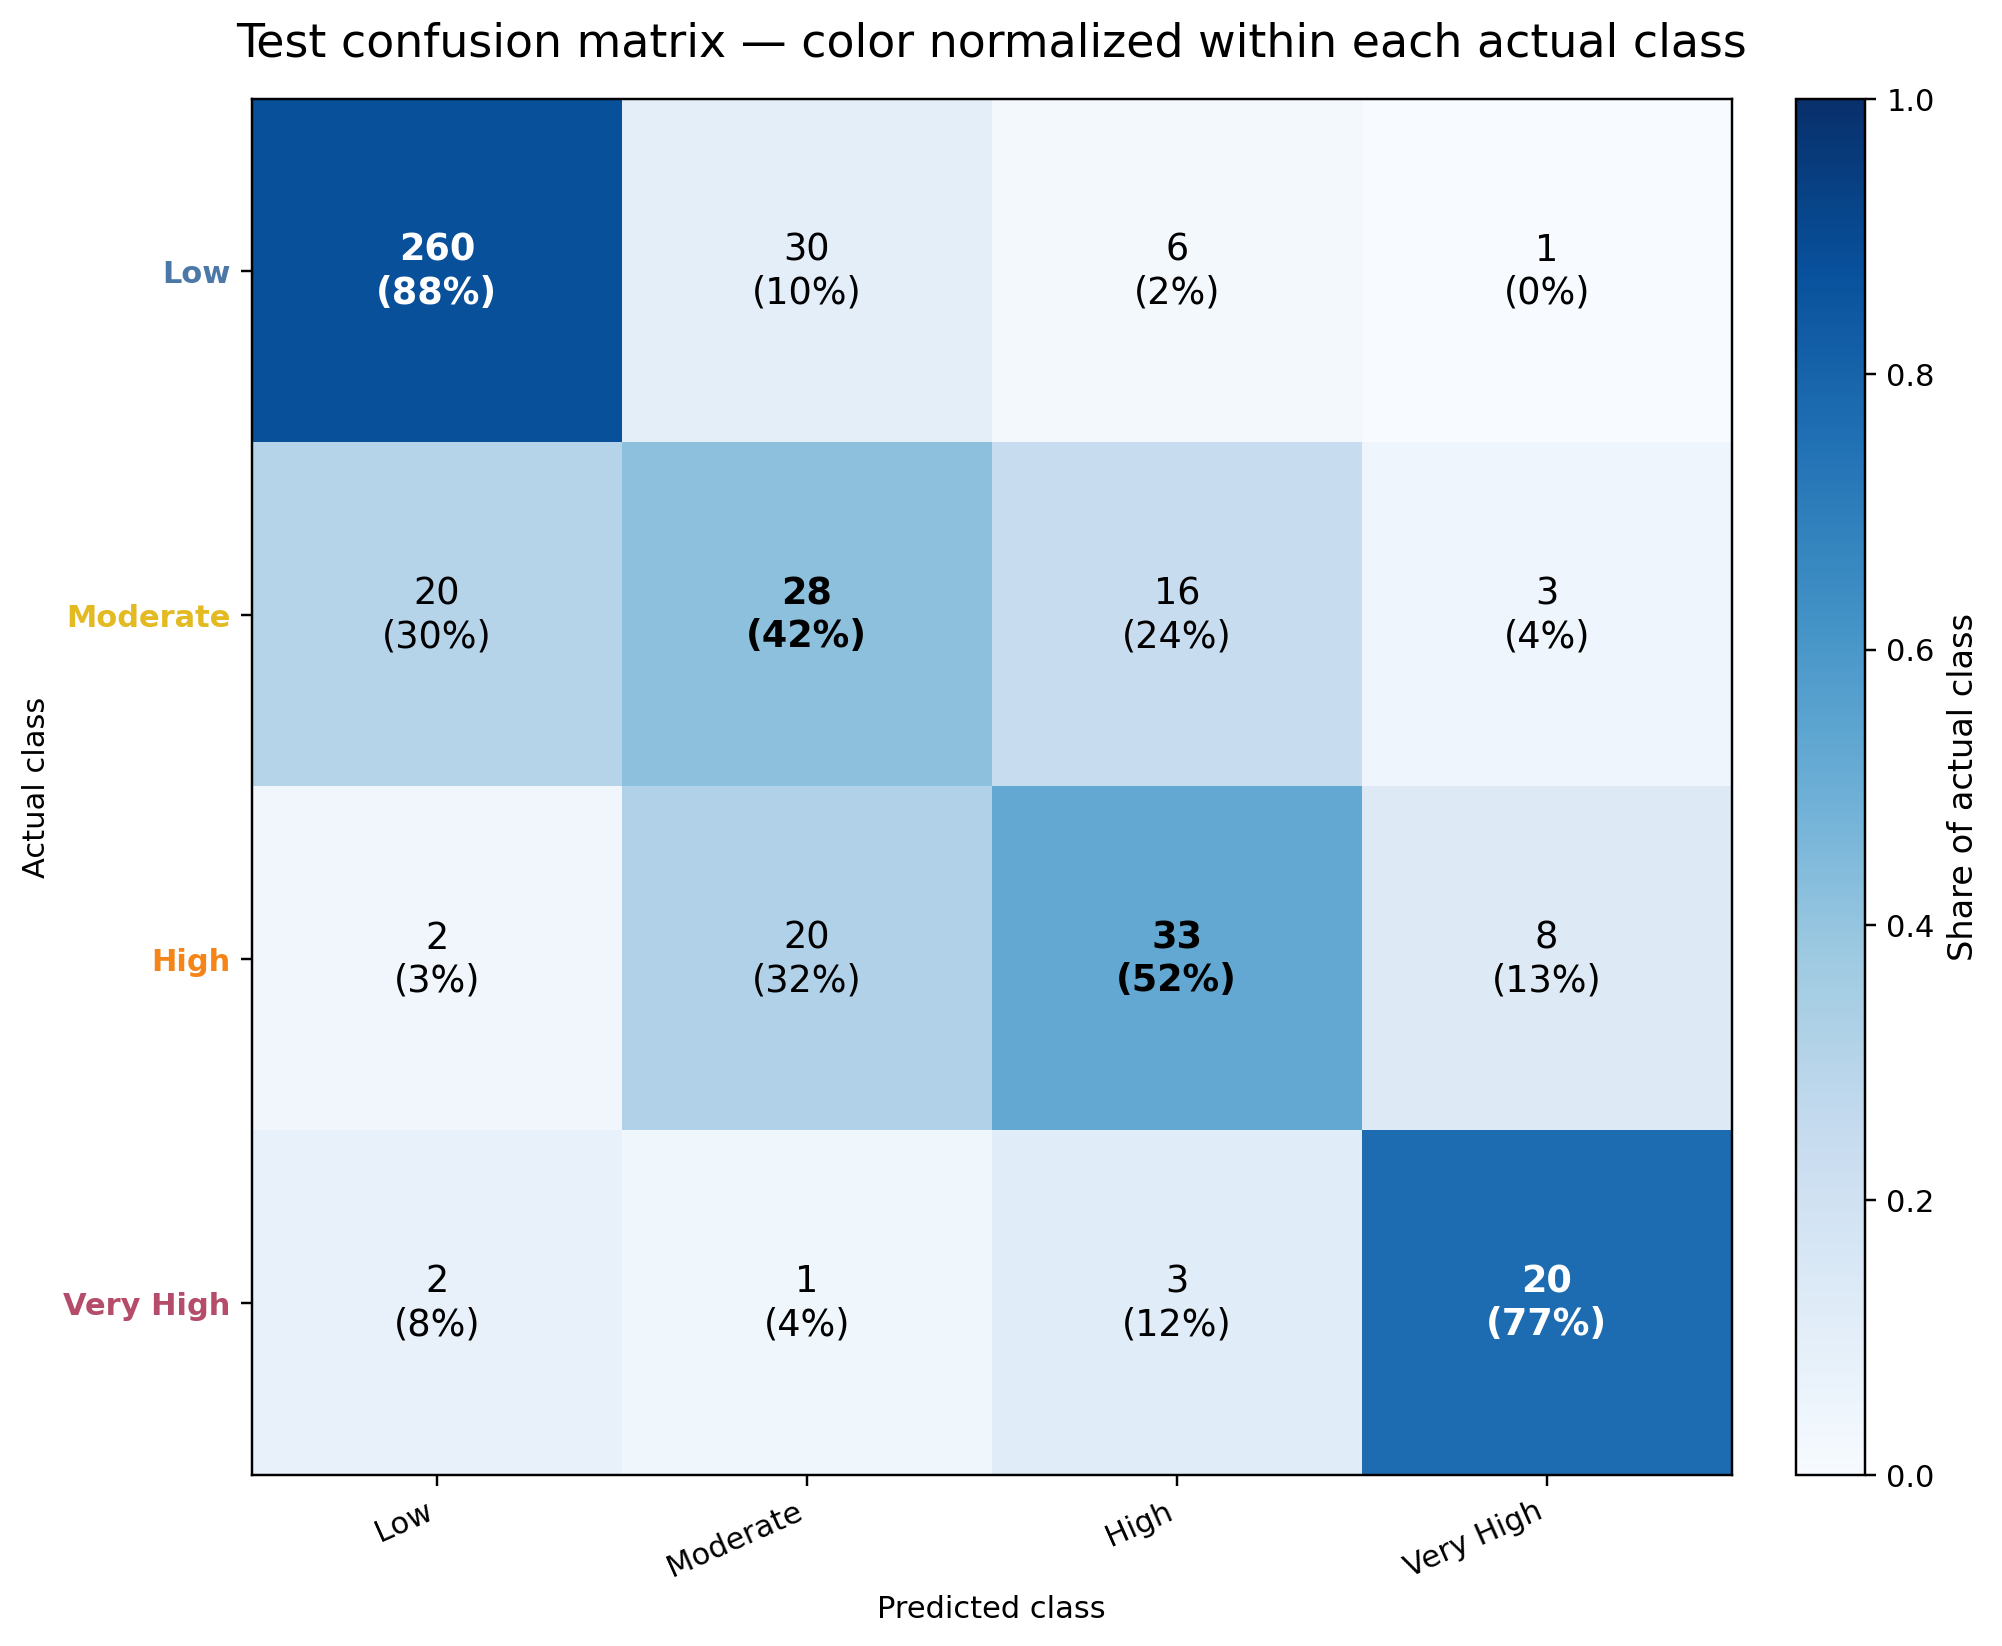

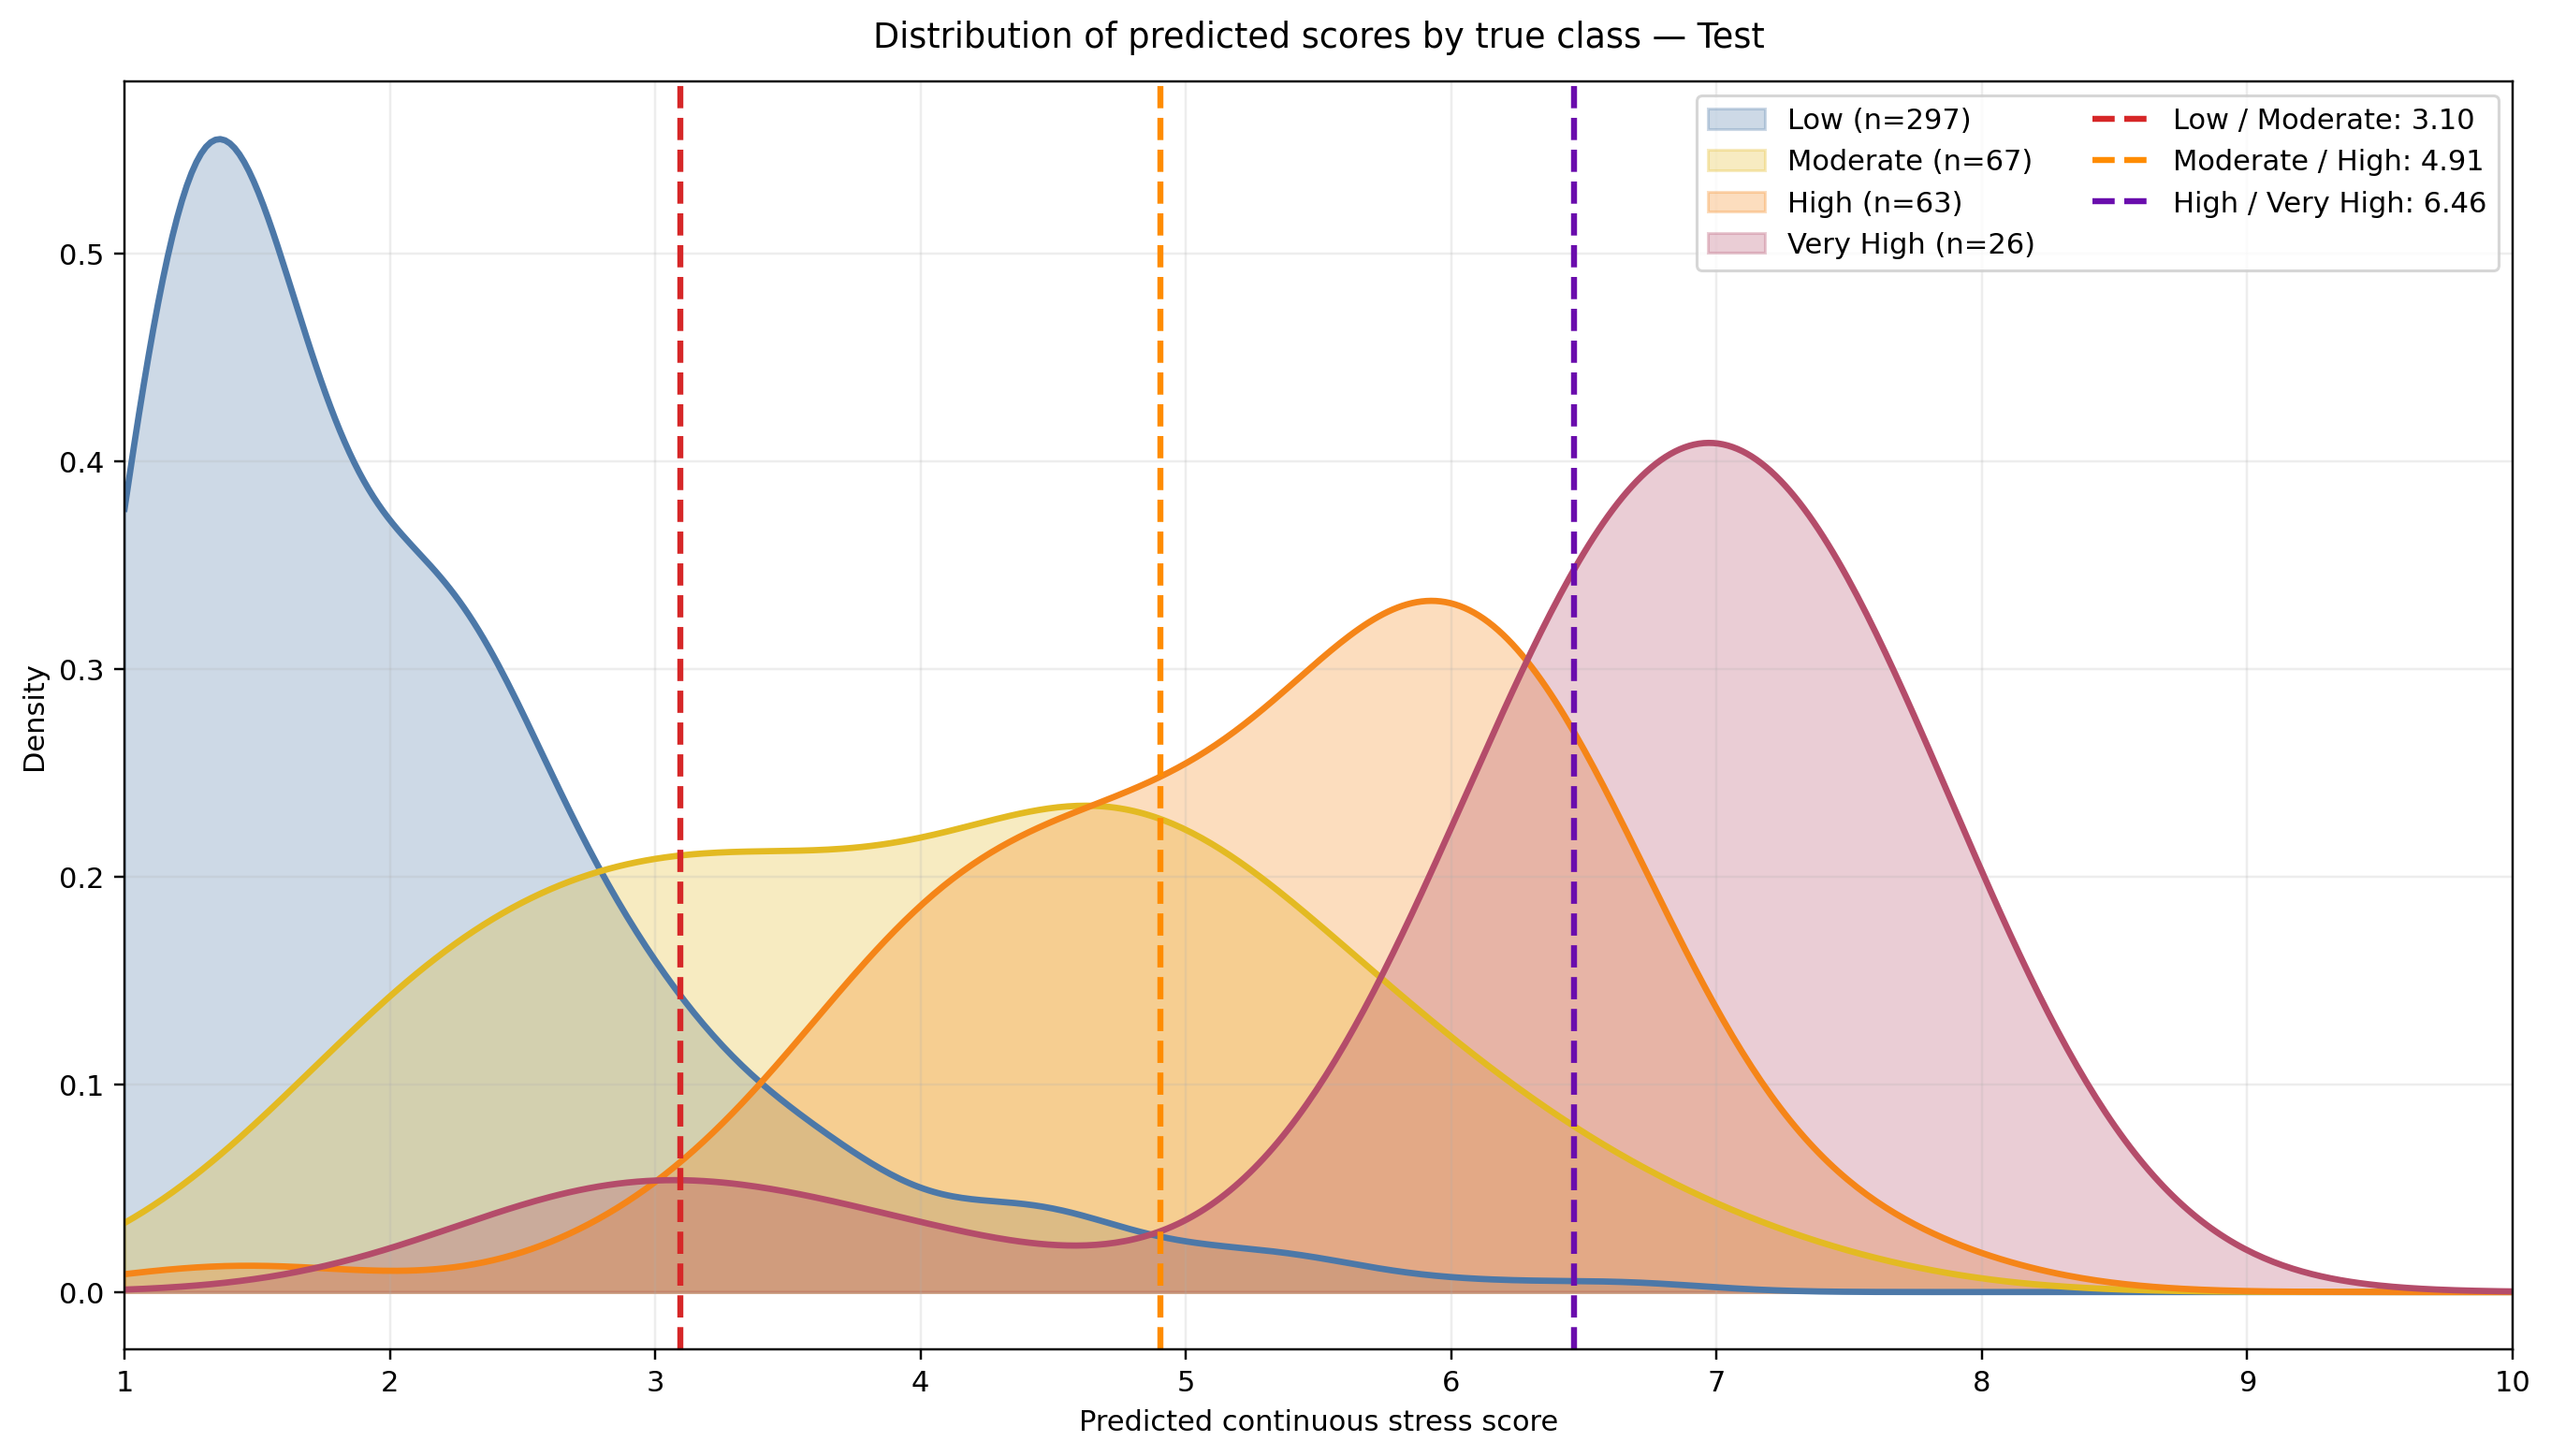

In [11]:
if REGENERATE_REPORT_FIGURES:
    run_command([
        PYTHON,
        ROOT / "src/generate_report_figures.py",
        "--project-root", RUN_ROOT,
        "--output-dir", RUN_ROOT / "outputs/report_figures",
    ])

    figure_manifest = pd.read_csv(
        RUN_ROOT / "outputs/report_figures/figure_manifest.csv"
    )
    display(figure_manifest.head(20))
    display(Image(
        filename=str(
            RUN_ROOT
            / "outputs/report_figures/test_confusion_matrix_row_normalized.png"
        ),
        width=700,
    ))
    display(Image(
        filename=str(
            RUN_ROOT
            / "outputs/report_figures/test_score_distribution_with_thresholds.png"
        ),
        width=900,
    ))
else:
    print("Report-figure regeneration was disabled.")

**Phase 8.4 result**

Both PNG and SVG outputs are produced. PNG is convenient for slides/documents; SVG preserves vector quality for publication.

The displayed confusion matrix is row-normalized, so each row sums to 100% and directly visualizes **recall distribution for that true class**. This is why it is especially useful when class supports are unequal.


# Final artifact verification — proving the saved system matches its declared contract

A successful notebook run should end by verifying artifacts, not merely by trusting that files exist.

`verify_artifacts.py` checks the selected model/bundle and expected outputs. The notebook then calculates SHA-256 hashes for the most important regenerated files.

This final step protects against:

- accidental use of the wrong candidate model;
- missing output tables;
- silent file replacement;
- mismatch between model and metadata bundle;
- unnoticed changes after reproduction.

Artifact-integrity checks and tests/assertions are audit mechanisms; neither replaces scientific validation.


In [12]:
run_command([
    PYTHON,
    ROOT / "src/verify_artifacts.py",
    "--project-root", RUN_ROOT,
])

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

tracked = [
    RUN_ROOT / "models/fusion_selected.cbm",
    RUN_ROOT / "models/fusion_scalar_fallback.cbm",
    RUN_ROOT / "models/fusion_bundle.json",
    RUN_ROOT / "outputs/candidate_leaderboard.csv",
    RUN_ROOT / "outputs/validation_metrics.json",
    RUN_ROOT / "outputs/fusion_oof_predictions.csv",
]
if RUN_LOCKED_TEST:
    tracked.extend([
        RUN_ROOT / "outputs/test_metrics.json",
        RUN_ROOT / "outputs/test_predictions.csv",
        RUN_ROOT / "outputs/final_metrics.json",
    ])

checksums = {
    str(path.relative_to(RUN_ROOT)): sha256_file(path)
    for path in tracked
}
(RUN_ROOT / "notebook_checksums.json").write_text(
    json.dumps(checksums, indent=2),
    encoding="utf-8",
)

print("All Phase 4–8 artifact checks passed.")
display(pd.DataFrame(
    [{"artifact": name, "sha256": digest} for name, digest in checksums.items()]
))


$ /opt/pyvenv/bin/python3 /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/src/verify_artifacts.py --project-root /mnt/data/memberC_reproducible_notebooks/MemberC_Phases_4_8/notebook_run


{
  "status": "valid",
  "files_checked": 12
}

All Phase 4–8 artifact checks passed.


,artifact,sha256
0,models/fusion_selected.cbm,b441032baa60ed370203120713e412c3595e85f05f34d6...
1,models/fusion_scalar_fallback.cbm,71ccced8fc905e53ec137c5e66a673fc3f447b50ce523e...
2,models/fusion_bundle.json,71bc114f9b1e6024d91f3798c30f8dbde2edb627458cc4...
3,outputs/candidate_leaderboard.csv,696df9dbae0573d1bfafff7b8ef256034e24ba8c54b1e6...
4,outputs/validation_metrics.json,fc328db7c4b0810d9e005ca37538a4707810883131cf6a...
5,outputs/fusion_oof_predictions.csv,238964ffd144f604365f152f45b9bf999c161d4c6525ee...
6,outputs/test_metrics.json,38e377c184422d3747a1fcc4adf7313fdebd1856ea3c08...
7,outputs/test_predictions.csv,9edf97b35748b48b60238e1b968bc00acb0cc018e5514b...
8,outputs/final_metrics.json,5f24e1d9bdc8c62fabc7b7bde921d4bbc561c17171fa6d...


# Part 4 completion — algorithmic path, final conclusion, and legitimate next step

The complete Part 4 reasoning chain is:

**leakage-safe base OOF scores → ID-aligned fusion matrix → simple baselines → learned scalar/hybrid stackers → validation-only constrained threshold search → model/threshold freeze → fusion OOF diagnostics → locked test → post-hoc SHAP/importance → temporal monitoring layer → active-learning acquisition → reproducible figures/artifacts**

Principal outputs include:

- `notebook_run/models/fusion_selected.cbm`
- `notebook_run/models/fusion_bundle.json`
- `notebook_run/outputs/candidate_leaderboard.csv`
- `notebook_run/outputs/validation_metrics.json`
- `notebook_run/outputs/fusion_oof_predictions.csv`
- `notebook_run/outputs/test_metrics.json`
- `notebook_run/outputs/global_feature_importance.csv`
- `notebook_run/outputs/validation_shap_summary.csv`
- `notebook_run/outputs/report_figures/`

## Final scientific conclusion

The selected fusion achieves locked-test **MAE 0.9174** and meets **3/4 internal recall objectives**. The Very High objective passes; Moderate is the main unresolved class boundary.

This supports continued evaluation as a **human-in-the-loop risk-monitoring / prioritization overlay**, not autonomous clinical use.

A possible operational flow is:

1. score each new post with the accepted base models and fusion;
2. update a user's temporally decayed state;
3. detect immediate, repeated, sustained, or rising patterns;
4. add qualifying cases to a private review queue;
5. let a trained human decide whether any support/escalation action is appropriate.

## Constraints on subsequent development

The opened 453-row test cannot be reused for optimization.

A legitimate improvement cycle should:

- acquire new dual annotations, especially near both Moderate boundaries and high model disagreement;
- tune only on new development/train/validation data;
- preserve grouped leakage controls;
- reserve a new untouched confirmation set before making final claims.

The central lesson of Part 4 is that a strong ensemble is not just “average two models.” It requires **leakage-safe base predictions, explicit baseline comparison, constrained validation-only calibration, strict test discipline, and an operational interpretation that respects the limits of the data**.
